# Notebook Statistika Deskriptif  
Pada notebook ini saya akan melakukan statistika deskriptif untuk semua kombinasi antara store dengan family untuk mencari tahu apa yang harus dilakukan kedepannya untuk TA 2

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy import stats
from scipy.stats import shapiro, levene, kruskal

import scikit_posthocs as sp

np.random.seed(10122097)

In [2]:
train = pd.read_csv("../datasets/train.csv", parse_dates=['date'])
test = pd.read_csv("../datasets/test.csv", parse_dates=['date'])
oil = pd.read_csv("../datasets/oil.csv", parse_dates=['date'])
holidays = pd.read_csv("../datasets/holidays_events.csv", parse_dates=['date'])
stores = pd.read_csv("../datasets/stores.csv")
transactions = pd.read_csv("../datasets/transactions.csv", parse_dates=['date'])

In [3]:
def plot_specific_store_family(specific_store, specific_family):
    ''' 
    Berikut merupakan fungsi yang menampilkan plot dari penjualan antara store dan family yang dipilih 
    ''' 
    
    df_specific = train[(train['store_nbr'] == specific_store) & (train['family'] == specific_family)]

    plt.figure(figsize=(20, 8))

    plt.plot(df_specific['date'], df_specific['sales'], color='tab:blue')
    plt.title(f'Tren Penjualan Toko {specific_store} - Keluarga Produk {specific_family}', fontsize=16)
    plt.xlabel('Tahun', fontsize=12)
    plt.ylabel('Penjualan', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

Pada bagian ini akan dilakukan statistika deskriptif yang melibatkan kombinasi antara store dengan family sebanyak 1782 kombinasi yang berbeda 

In [4]:
def compute_descriptive_stats(df, store, family): 
    ''' 
    Berikut merupakan fungsi yang akan menghitung statistika deskriptif dari 1 kombinasi store dan family
    ''' 

    series = df[(df['store_nbr'] == store) & (df['family'] == family)]
    series = series.groupby('date')['sales'].sum().reset_index()
    sales = series['sales'].values

    if len(sales) == 0:
        return None

    non_zero = sales[sales > 0]

    stats_dict = {
        'store_nbr': store,
        'family': family,
        'n_days': len(non_zero),
        'mean': np.mean(sales),
        'median': np.median(sales),
        'std': np.std(sales),
        'min': np.min(sales),
        'max': np.max(sales),
        'skewness': stats.skew(sales),
        'kurtosis': stats.kurtosis(sales),
        'cv': np.std(sales) / (np.mean(sales) + 1e-9),
    }

    if len(non_zero) > 0:
        stats_dict['adi'] = len(sales) / len(non_zero)
        stats_dict['cv2'] = (np.std(non_zero) / (np.mean(non_zero) + 1e-9)) ** 2
    else: 
        stats_dict['adi'] = np.nan
        stats_dict['cv2'] = np.nan
    
    return stats_dict

In [5]:
all_combinations = train[['store_nbr', 'family']].drop_duplicates().values
results = []

for store, family in all_combinations:
    res = compute_descriptive_stats(train, store, family)
    if res is not None:
        results.append(res)

In [6]:
df_full_stats = pd.DataFrame(results)
print(f'Total kombinasi yang dianalisis: {len(df_full_stats)}')

Total kombinasi yang dianalisis: 1782


In [7]:
df_full_stats.describe()

,store_nbr,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2
count,1782.000000,1782.000000,1782.000000,1782.000000,1782.000000,1782.0,1782.000000,1729.000000,1729.000000,1782.000000,1729.000000,1729.000000
mean,27.500000,1156.991021,357.775749,339.568151,194.920879,0.0,1788.976595,3.255207,44.346780,1.449029,4.927673,0.718332
std,15.590159,543.741292,961.853944,936.768942,501.898340,0.0,5933.640834,4.709972,142.661362,2.132810,25.699766,2.695675
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,-1.795701,-1.596156,0.000000,1.002978,0.000000
25%,14.000000,835.250000,2.890736,0.000000,3.574362,0.0,30.115500,0.858982,0.993637,0.457614,1.002978,0.152990
50%,27.500000,1168.000000,19.812350,11.000000,19.868865,0.0,218.000000,1.585963,4.400650,0.995987,1.319749,0.338390
75%,41.000000,1679.000000,221.011728,197.875000,132.023773,0.0,1192.190750,3.696216,23.053388,1.452235,1.890011,0.576437
max,54.000000,1679.000000,9730.436483,8975.500000,5569.184157,0.0,124717.000000,40.198841,1635.210766,29.019905,561.333333,85.516636


#### Plot ADI dan CV^2

Berikut ini akan dilakukan uji $ADI$ (Average Demand Interval) dan $CV^2$ (Squared Coefficient of Variation) untuk mengetahui pengelompokkan jenis dari time series yang sedang kita hadapi. Pada kasus ini terdapat 4 klasifikasi utama yaitu  

1. **Smooth Demand** $(ADI < 1.32, CV^2 < 0.49)$  : Berikut merupakan jenis permintaan yang sangat biasa dalam waktu dan kuantitas permintaan. Sehingga dapat di prediksi dengan lebih mudah dan galat relatif akan tidak terlalu besar.
2. **Intermittent Demand** $(ADI >= 1.32, CV^2 < 0.49)$ : Berikut jenis permintaan yang dalam satuan kuantitas permintaan variasinya biasa (tidak terlalu berbeda) namun dalam satuan waktu variasinya relatif lebih besar. 
3. **Erratic Demand** $(ADI < 1.32, CV^2 >= 0.49)$ : Pada klasifikasi ini satuan waktu variasinya relatif lebih biasa (tidak terlalu jauh), namun dalam satuan permintaan variasinya relatif lebih besar.
4. **Lumpy Demand** $(ADI >= 1.32, CV^2 >= 0.49)$ : Terakhir pada klasifikasi ini kedua satuan sama sama memiliki variasi yang besar sehingga sangat sulit untuk di prediksi.

In [8]:
def categorize_demand(row):
    adi = row['adi']
    cv2 = row['cv2']
    if pd.isna(adi) or pd.isna(cv2):
        return 'No Sales'
    if adi < 1.32 and cv2 < 0.49:
        return 'Smooth'
    elif adi >= 1.32 and cv2 < 0.49:
        return 'Intermittent'
    elif adi < 1.32 and cv2 >= 0.49:
        return 'Erratic'
    else:
        return 'Lumpy'

df_full_stats['category'] = df_full_stats.apply(categorize_demand, axis=1)
print('=== Ringkasan Distribusi Kategori Permintaan (Semua Kombinasi) ===')
print(df_full_stats['category'].value_counts())

=== Ringkasan Distribusi Kategori Permintaan (Semua Kombinasi) ===
category
Smooth          630
Intermittent    541
Lumpy           323
Erratic         235
No Sales         53
Name: count, dtype: int64


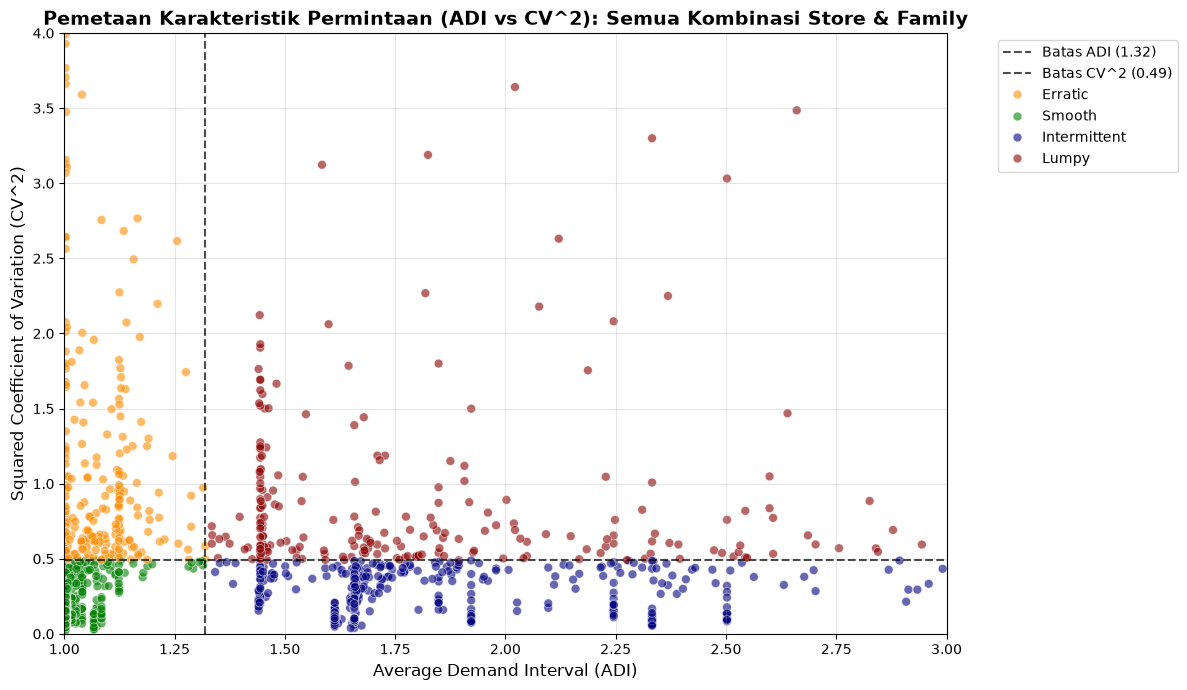

In [9]:
# Plot ADI vs CV^2 untuk Keseluruhan Kombinasi Store & Family
plot_df = df_full_stats.dropna(subset=['adi', 'cv2']).copy()

plt.figure(figsize=(12, 7))
ax = plt.gca()

plt.axvline(x=1.32, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label='Batas ADI (1.32)')
plt.axhline(y=0.49, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label='Batas CV^2 (0.49)')

# plt.xscale('log')
# plt.yscale('log')

palette = {
    'Smooth': 'green',
    'Intermittent': 'navy',
    'Erratic': 'darkorange',
    'Lumpy': 'darkred'
}

sns.scatterplot(
    x='adi', y='cv2',
    hue='category',
    data=plot_df,
    palette=palette,
    alpha=0.6,
    s=40
)

plt.title('Pemetaan Karakteristik Permintaan (ADI vs CV^2): Semua Kombinasi Store & Family', fontsize=14, fontweight='bold')
plt.xlabel('Average Demand Interval (ADI)', fontsize=12)
plt.ylabel('Squared Coefficient of Variation (CV^2)', fontsize=12)
plt.xlim([1, 3])
plt.ylim([0, 4])
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

In [10]:
df_full_stats

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
0,1,AUTOMOTIVE,1463,3.251188,3.0000,2.758785,0.0,19.000,1.394908,2.944256,0.848547,1.151059,0.494303,Erratic
1,1,BABY CARE,0,0.000000,0.0000,0.000000,0.0,0.000,NaN,NaN,0.000000,NaN,NaN,No Sales
2,1,BEAUTY,1430,2.408551,2.0000,1.898386,0.0,12.000,1.012293,1.407079,0.788186,1.177622,0.376704,Smooth
3,1,BEVERAGES,1678,1587.748812,1674.0000,726.654208,0.0,5051.000,0.176872,-0.721302,0.457663,1.003576,0.205146,Smooth
4,1,BOOKS,127,0.125297,0.0000,0.536419,0.0,8.000,6.492349,58.386677,4.281179,13.259843,0.457672,Intermittent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777,9,POULTRY,1679,483.880389,454.7850,164.129266,0.0,2198.853,1.342712,7.354173,0.339194,1.002978,0.111742,Smooth
1778,9,PREPARED FOODS,1679,88.762428,82.1865,35.037132,0.0,311.147,0.923715,1.572763,0.394729,1.002978,0.152379,Smooth
1779,9,PRODUCE,1016,969.134497,1122.1520,880.186206,0.0,4059.907,0.235316,-1.115796,0.908219,1.657480,0.100985,Intermittent
1780,9,SCHOOL AND OFFICE SUPPLIES,901,6.051069,1.0000,22.283794,0.0,326.000,7.911502,75.157282,3.682621,1.869034,6.791027,Lumpy


In [11]:
df_full_stats.to_csv('descriptive_stats_all_combinations.csv', index=False)

In [12]:
df_full_stats[(df_full_stats['store_nbr'] == 44) & (df_full_stats['category'] == 'Smooth')]

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
1254,44,AUTOMOTIVE,1679,18.871734,17.0000,9.728326,0.0,89.000,1.070680,2.804215,0.515497,1.002978,0.261979,Smooth
1257,44,BEVERAGES,1679,7967.849762,7585.5000,3883.917494,0.0,25413.000,0.916229,0.684657,0.487449,1.002978,0.233932,Smooth
1259,44,BREAD/BAKERY,1679,1385.426531,1295.9165,481.812700,0.0,3361.502,0.890392,0.929961,0.347772,1.002978,0.117617,Smooth
1261,44,CLEANING,1679,2558.349169,2408.5000,677.516535,0.0,5869.000,0.710089,1.186167,0.264826,1.002978,0.066955,Smooth
1262,44,DAIRY,1679,2540.352732,2369.0000,851.697046,0.0,5636.000,0.663983,0.198528,0.335267,1.002978,0.109101,Smooth
1263,44,DELI,1679,596.611662,529.6565,208.247064,0.0,1368.412,0.814903,0.113976,0.349050,1.002978,0.118505,Smooth
1264,44,EGGS,1679,648.375297,588.0000,205.140076,0.0,1375.000,0.740441,0.179093,0.316391,1.002978,0.096837,Smooth
1266,44,GROCERY I,1679,9730.436483,8804.0000,3575.024149,0.0,46271.000,1.862983,9.824374,0.367406,1.002978,0.131618,Smooth
1267,44,GROCERY II,1679,81.520190,76.0000,32.722982,0.0,369.000,1.753975,8.891339,0.401410,1.002978,0.157682,Smooth
1276,44,"LIQUOR,WINE,BEER",1498,328.920428,267.5000,223.242816,0.0,1591.000,0.982205,1.556698,0.678714,1.124166,0.299321,Smooth


In [13]:
df_full_stats[(df_full_stats['store_nbr'] == 44) & (df_full_stats['category'] == 'Erratic')]

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
1256,44,BEAUTY,1670,11.652019,10.0000,8.314058,0.0,136.000,3.124107,31.811846,0.713529,1.008383,0.496578,Erratic
1265,44,FROZEN FOODS,1679,606.350648,468.0365,658.003580,0.0,10092.619,7.124491,64.558627,1.085187,1.002978,1.171164,Erratic
1268,44,HARDWARE,1553,4.176960,3.0000,3.287425,0.0,31.000,1.496556,4.571804,0.787038,1.084353,0.493452,Erratic
1274,44,LAWN AND GARDEN,1624,12.958432,10.0000,12.433459,0.0,147.000,2.731264,15.826966,0.959488,1.036946,0.852187,Erratic
1275,44,LINGERIE,1678,19.280879,16.0000,13.954629,0.0,216.000,3.670067,31.391590,0.723755,1.003576,0.518392,Erratic
1284,44,PRODUCE,1603,6333.763942,7674.4205,5569.184157,0.0,17850.615,0.052477,-1.466561,0.879285,1.050530,0.687855,Erratic


In [14]:
df_full_stats[(df_full_stats['store_nbr'] == 44) & (df_full_stats['category'] == 'Intermittent')]

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
1271,44,HOME APPLIANCES,1117,1.909739,2.0,1.989921,0.0,11.0,1.158828,1.327962,1.041986,1.507610,0.383472,Intermittent
1272,44,HOME CARE,1044,399.149050,436.5,375.640488,0.0,2214.0,0.671296,0.380119,0.941103,1.613027,0.169029,Intermittent
1273,44,LADIESWEAR,1016,19.861045,18.0,20.778887,0.0,100.0,0.891874,0.284427,1.046213,1.657480,0.263703,Intermittent
1280,44,PET SUPPLIES,1010,20.277316,19.0,21.180755,0.0,106.0,0.914630,0.484560,1.044554,1.667327,0.254159,Intermittent
1281,44,PLAYERS AND ELECTRONICS,1016,26.316508,27.0,25.862283,0.0,156.0,0.717110,0.258670,0.982740,1.657480,0.186004,Intermittent


In [15]:
df_full_stats[(df_full_stats['store_nbr'] == 44) & (df_full_stats['category'] == 'Lumpy')]

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
1258,44,BOOKS,166,0.313539,0.0,1.706570,0.0,51.0,17.790753,474.278960,5.442925,10.144578,2.018896,Lumpy
1260,44,CELEBRATION,1016,22.430523,19.0,38.595279,0.0,919.0,13.443333,280.976000,1.720659,1.657480,1.389571,Lumpy
1269,44,HOME AND KITCHEN I,1166,80.060570,70.0,102.944672,0.0,1935.0,7.384309,107.854716,1.285835,1.444254,0.837192,Lumpy
1270,44,HOME AND KITCHEN II,1166,60.378860,38.0,81.982148,0.0,1568.0,6.498562,92.260712,1.357796,1.444254,0.968912,Lumpy
1277,44,MAGAZINES,1060,11.431116,6.0,13.862170,0.0,74.0,1.355530,1.656050,1.212670,1.588679,0.555108,Lumpy
1285,44,SCHOOL AND OFFICE SUPPLIES,1010,17.543349,5.0,56.154097,0.0,740.0,7.127683,63.804933,3.200877,1.667327,5.744696,Lumpy


In [16]:
df_full_stats[(df_full_stats['store_nbr'] == 44) & (df_full_stats['category'] == 'No Sales')]

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
1255,44,BABY CARE,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,No Sales


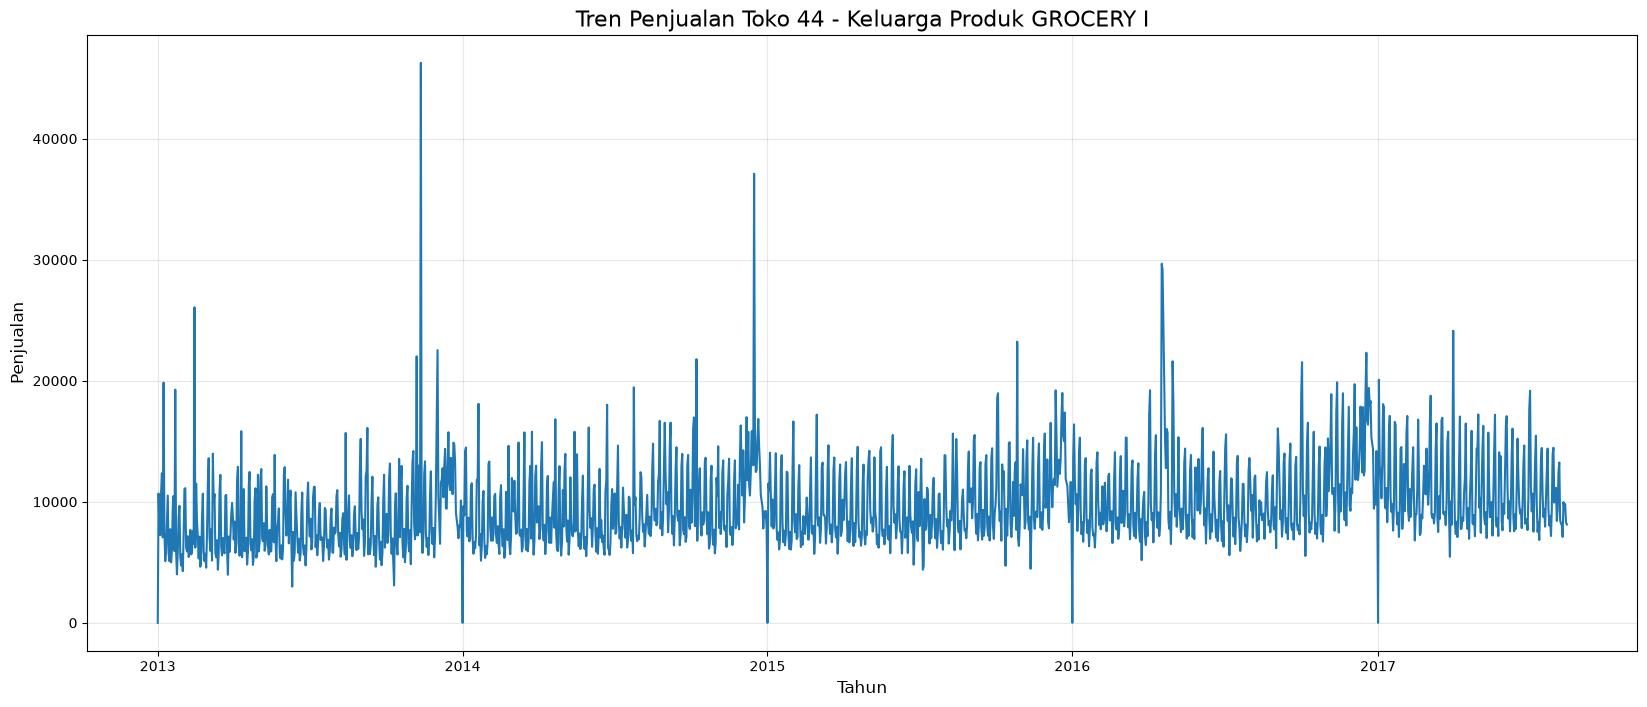

In [17]:
plot_specific_store_family(44, 'GROCERY I')

In [18]:
df_full_stats[(df_full_stats['store_nbr'] == 44) & (df_full_stats['family'] == 'GROCERY I')]

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
1266,44,GROCERY I,1679,9730.436483,8804.0,3575.024149,0.0,46271.0,1.862983,9.824374,0.367406,1.002978,0.131618,Smooth


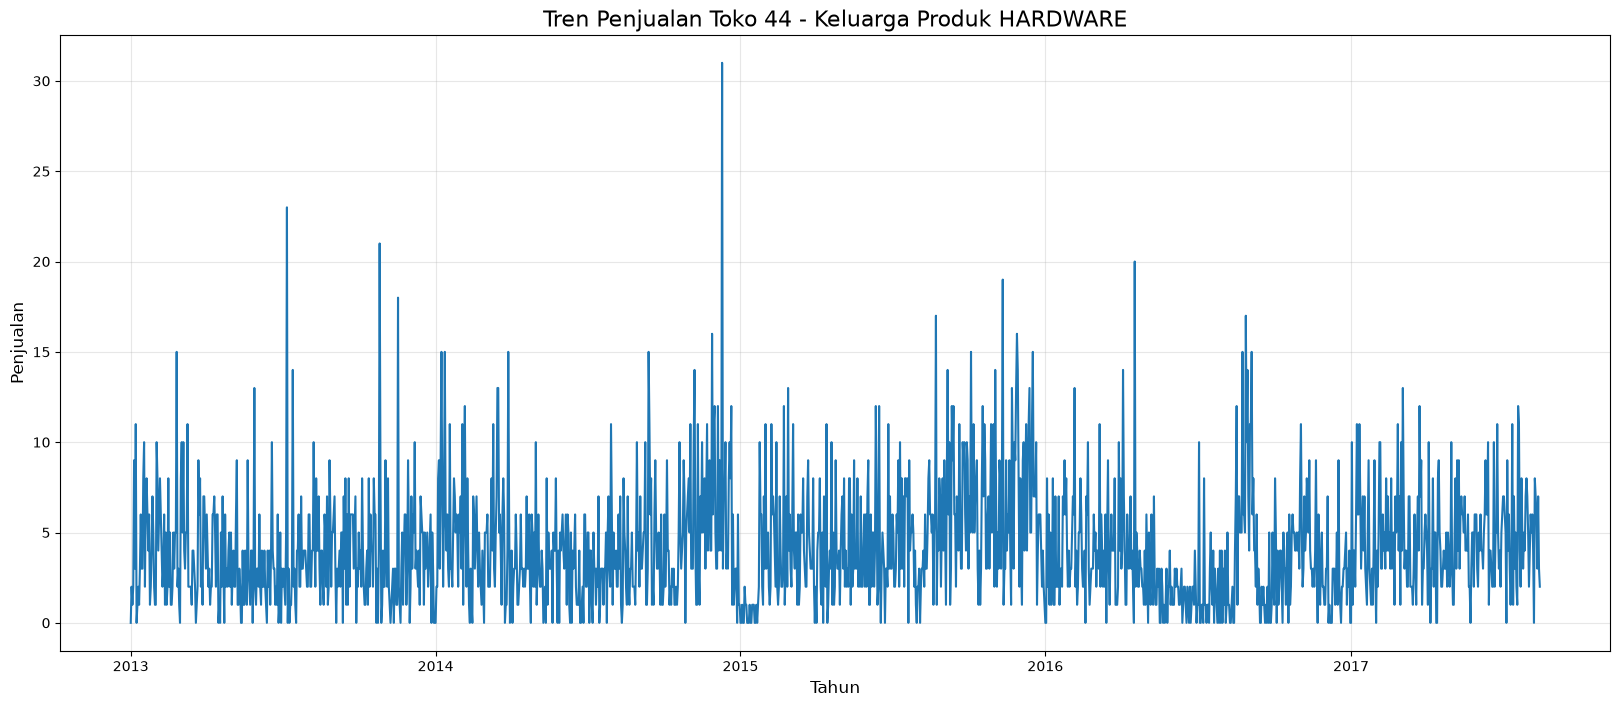

In [19]:
plot_specific_store_family(44, 'HARDWARE')

In [20]:
df_full_stats[(df_full_stats['store_nbr'] == 44) & (df_full_stats['family'] == 'HARDWARE')]

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
1268,44,HARDWARE,1553,4.17696,3.0,3.287425,0.0,31.0,1.496556,4.571804,0.787038,1.084353,0.493452,Erratic


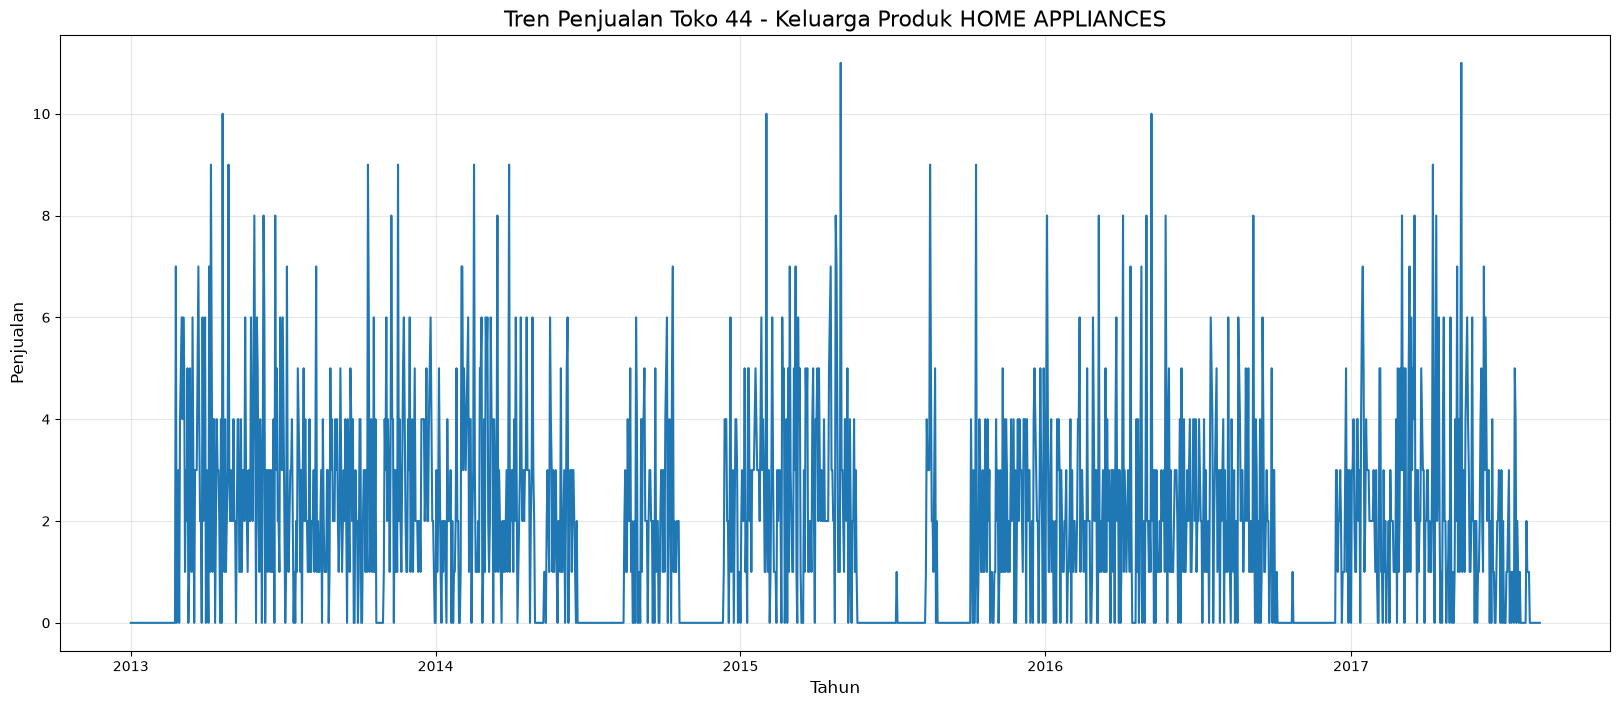

In [21]:
plot_specific_store_family(44, 'HOME APPLIANCES')

In [22]:
df_full_stats[(df_full_stats['store_nbr'] == 44) & (df_full_stats['family'] == 'HOME APPLIANCES')]

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
1271,44,HOME APPLIANCES,1117,1.909739,2.0,1.989921,0.0,11.0,1.158828,1.327962,1.041986,1.50761,0.383472,Intermittent


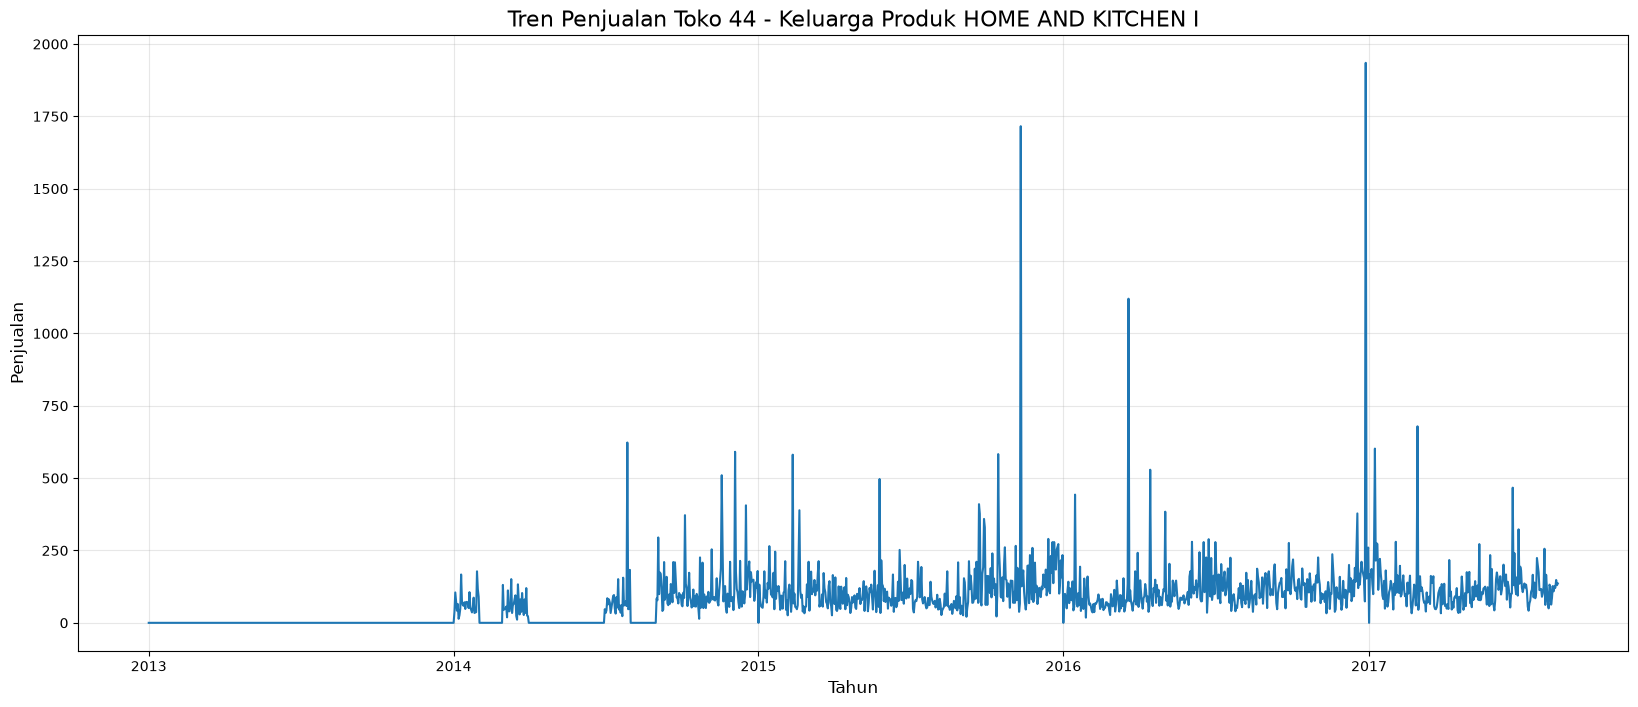

In [23]:
plot_specific_store_family(44, 'HOME AND KITCHEN I')

In [24]:
df_full_stats[(df_full_stats['store_nbr'] == 44) & (df_full_stats['family'] == 'HOME AND KITCHEN I')]

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
1269,44,HOME AND KITCHEN I,1166,80.06057,70.0,102.944672,0.0,1935.0,7.384309,107.854716,1.285835,1.444254,0.837192,Lumpy


#### Analisis Karakteristik Semua Family  
Berikut dibawah ini akan dilakukan analisis lebih lanjut dari masing-masing family seperti apa karakteristiknya berdasarkan ADI dan CV^2 dari semua store

In [25]:
store_category_ct = pd.crosstab(df_full_stats['family'], df_full_stats['category'])

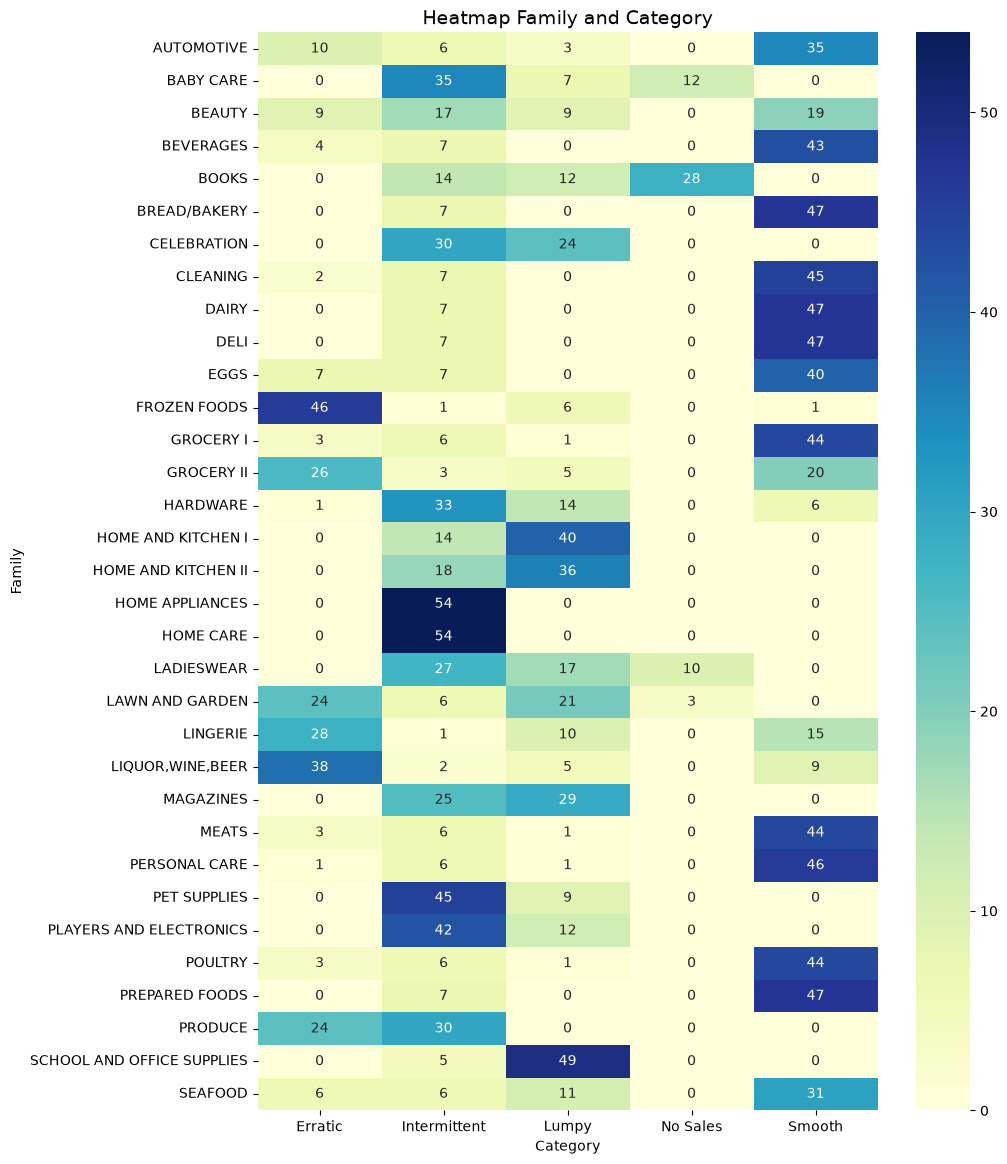

In [26]:
plt.figure(figsize=(10,14))
sns.heatmap(store_category_ct, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Heatmap Family and Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Family')
plt.show()

In [27]:
family_summary = df_full_stats.groupby('family')[['adi', 'cv2']].mean().sort_values('cv2')

family_summary.head()

,adi,cv2
family,,
BREAD/BAKERY,1.371014,0.112319
DELI,1.371026,0.114248
HOME CARE,1.913520,0.122334
CLEANING,1.371037,0.139698
PREPARED FOODS,1.371273,0.153211


In [28]:
family_summary.tail()

,adi,cv2
family,,
LAWN AND GARDEN,57.032464,1.477042
CELEBRATION,1.995850,1.482650
MEATS,1.371026,1.826811
FROZEN FOODS,1.371325,2.639770
SCHOOL AND OFFICE SUPPLIES,6.675384,3.822616


In [29]:
family_category_count = df_full_stats.groupby('family')['category'].value_counts()

family_category_count

family                      category    
AUTOMOTIVE                  Smooth          35
                            Erratic         10
                            Intermittent     6
                            Lumpy            3
BABY CARE                   Intermittent    35
                                            ..
SCHOOL AND OFFICE SUPPLIES  Intermittent     5
SEAFOOD                     Smooth          31
                            Lumpy           11
                            Intermittent     6
                            Erratic          6
Name: count, Length: 96, dtype: int64

In [30]:
consistency = df_full_stats.groupby('family')['category'].agg(
    lambda x: x.value_counts(normalize=True).iloc[0]
).sort_values(ascending=False)

print('Family paling konsisten kategorinya: ')
print(consistency.head())
print('\n Family paling bervariasi: ')
print(consistency.tail())

Family paling konsisten kategorinya: 
family
HOME CARE                     1.000000
HOME APPLIANCES               1.000000
SCHOOL AND OFFICE SUPPLIES    0.907407
PREPARED FOODS                0.870370
DAIRY                         0.870370
Name: category, dtype: float64

 Family paling bervariasi: 
family
LINGERIE           0.518519
LADIESWEAR         0.500000
GROCERY II         0.481481
LAWN AND GARDEN    0.444444
BEAUTY             0.351852
Name: category, dtype: float64


In [31]:
consistency

family
HOME CARE                     1.000000
HOME APPLIANCES               1.000000
SCHOOL AND OFFICE SUPPLIES    0.907407
PREPARED FOODS                0.870370
DAIRY                         0.870370
DELI                          0.870370
BREAD/BAKERY                  0.870370
PERSONAL CARE                 0.851852
FROZEN FOODS                  0.851852
PET SUPPLIES                  0.833333
CLEANING                      0.833333
POULTRY                       0.814815
MEATS                         0.814815
GROCERY I                     0.814815
BEVERAGES                     0.796296
PLAYERS AND ELECTRONICS       0.777778
EGGS                          0.740741
HOME AND KITCHEN I            0.740741
LIQUOR,WINE,BEER              0.703704
HOME AND KITCHEN II           0.666667
AUTOMOTIVE                    0.648148
BABY CARE                     0.648148
HARDWARE                      0.611111
SEAFOOD                       0.574074
CELEBRATION                   0.555556
PRODUCE           

#### Investigasi Fitur Type  
Terdapat beberapa uji statistik yaitu  
1. Uji Normalitas Shapiro-Wilk
2. Uji Rerata Kruskal-Wallis

In [32]:
store_total_sales = train.groupby('store_nbr')['sales'].sum().reset_index()
store_total_sales = store_total_sales.merge(stores, on='store_nbr')

store_total_sales

,store_nbr,sales,city,state,type,cluster
0,1,1.414501e+07,Quito,Pichincha,D,13
1,2,2.155739e+07,Quito,Pichincha,D,13
2,3,5.048191e+07,Quito,Pichincha,D,8
3,4,1.890970e+07,Quito,Pichincha,D,9
4,5,1.559240e+07,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,2.518368e+07,Quito,Pichincha,D,13
6,7,2.695205e+07,Quito,Pichincha,D,8
7,8,3.049429e+07,Quito,Pichincha,D,8
8,9,2.640944e+07,Quito,Pichincha,B,6
9,10,9.613906e+06,Quito,Pichincha,C,15


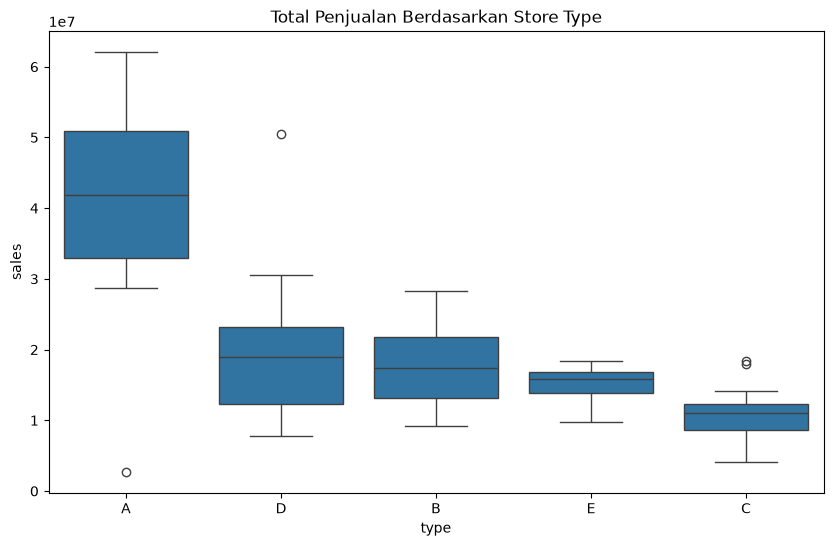

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=store_total_sales, x='type', y='sales', order=['A', 'D', 'B', 'E', 'C'])
plt.title('Total Penjualan Berdasarkan Store Type')
plt.show()

In [34]:
store_total_sales.groupby('type')['sales'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
type,,,,
A,3.922709e+07,4.189606e+07,1.737437e+07,9
B,1.815758e+07,1.741880e+07,6.631492e+06,8
C,1.096232e+07,1.098641e+07,3.949682e+06,15
D,1.950463e+07,1.888485e+07,1.000358e+07,18
E,1.495561e+07,1.585706e+07,3.710462e+06,4


In [35]:
print('=== Uji Normalitas Shapiro-Wilk Per Type ===')

for t in ['A', 'B', 'C', 'D', 'E']:
    data = store_total_sales[store_total_sales['type'] == t]['sales']
    if len(data) >= 3:
        stat, p = shapiro(data)
        normal = 'Normal' if p > 0.05 else 'Tidak Normal'
        print(f'Type {t} (n={len(data)}): p-value={p:.4f} -> {normal}')

=== Uji Normalitas Shapiro-Wilk Per Type ===
Type A (n=9): p-value=0.5752 -> Normal
Type B (n=8): p-value=0.6727 -> Normal
Type C (n=15): p-value=0.5326 -> Normal
Type D (n=18): p-value=0.0095 -> Tidak Normal
Type E (n=4): p-value=0.4785 -> Normal


Akan ditinjau terlebih dahulu mengapa Type D kesimpulannya tidak normal

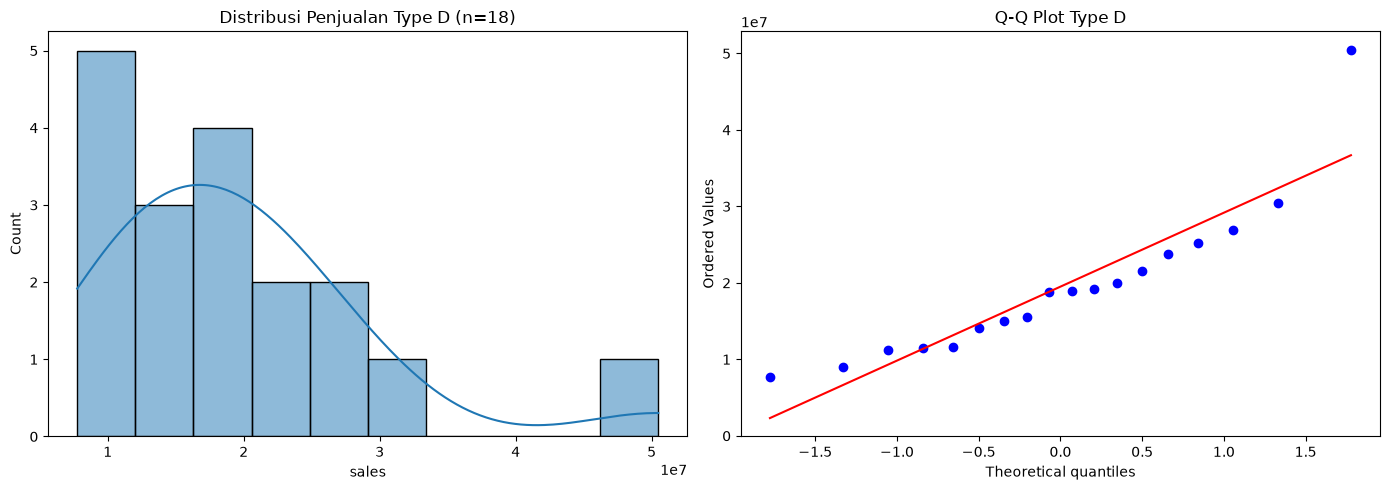

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_D = store_total_sales[store_total_sales['type'] == 'D']['sales']
sns.histplot(data_D, kde=True, ax=axes[0], bins=10)
axes[0].set_title(f'Distribusi Penjualan Type D (n={len(data_D)})')

stats.probplot(data_D, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot Type D')

plt.tight_layout()
plt.show()

In [37]:
data_type_D_sorted = store_total_sales[store_total_sales['type'] == 'D'].sort_values('sales', ascending=False)

data_type_D_sorted

,store_nbr,sales,city,state,type,cluster
2,3,5.048191e+07,Quito,Pichincha,D,8
7,8,3.049429e+07,Quito,Pichincha,D,8
6,7,2.695205e+07,Quito,Pichincha,D,8
5,6,2.518368e+07,Quito,Pichincha,D,13
23,24,2.376773e+07,Guayaquil,Guayas,D,1
1,2,2.155739e+07,Quito,Pichincha,D,13
36,37,1.997064e+07,Cuenca,Azuay,D,2
26,27,1.918802e+07,Daule,Guayas,D,1
3,4,1.890970e+07,Quito,Pichincha,D,9
37,38,1.886000e+07,Loja,Loja,D,4


In [38]:
data_type_D_sorted['cluster'].unique()

array([ 8, 13,  1,  2,  9,  4, 10])

In [39]:
data_D = store_total_sales[store_total_sales['type'] == 'D']['sales']

Q1 = data_D.quantile(0.25)
Q3 = data_D.quantile(0.75)
IQR = Q3 = Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data_D[(data_D < lower_bound) | (data_D > upper_bound)]
print(f'Batas atas outlier : {upper_bound:.4f}')

Batas atas outlier : 30686971.8090


In [40]:
data_type_D_no_outlier = data_D[~data_D.index.isin(outliers.index)]
stat, p = shapiro(data_type_D_no_outlier)
print(f'Shapiro-Wilk Tanpa Outlier (n={len(data_type_D_no_outlier)}): p-value={p:.4f}')
print('Kesimpulan Normal' if p > 0.05 else 'Kesimpulan Tetap Tidak Normal')

Shapiro-Wilk Tanpa Outlier (n=17): p-value=0.8055
Kesimpulan Normal


In [41]:
groups = [store_total_sales[store_total_sales['type'] == t]['sales'].values for t in ['A', 'B', 'C', 'D', 'E']]

In [42]:
stat_kw, p_kw = kruskal(*groups)
print(f'Uji Kruskal-Wallis : Statistik H = {stat_kw:.4f}, p-value = {p_kw:.4f}')

Uji Kruskal-Wallis : Statistik H = 21.4630, p-value = 0.0003


In [43]:
dunn_result = sp.posthoc_dunn(store_total_sales, val_col='sales', group_col='type', p_adjust='bonferroni')

dunn_result

,A,B,C,D,E
A,1.000000,0.466502,0.000064,0.262126,0.314918
B,0.466502,1.000000,0.325221,1.000000,1.000000
C,0.000064,0.325221,1.000000,0.044208,1.000000
D,0.262126,1.000000,0.044208,1.000000,1.000000
E,0.314918,1.000000,1.000000,1.000000,1.000000


#### Investigasi Fitur Cluster

In [44]:
location_cluster = pd.crosstab(stores['state'], stores['cluster'])

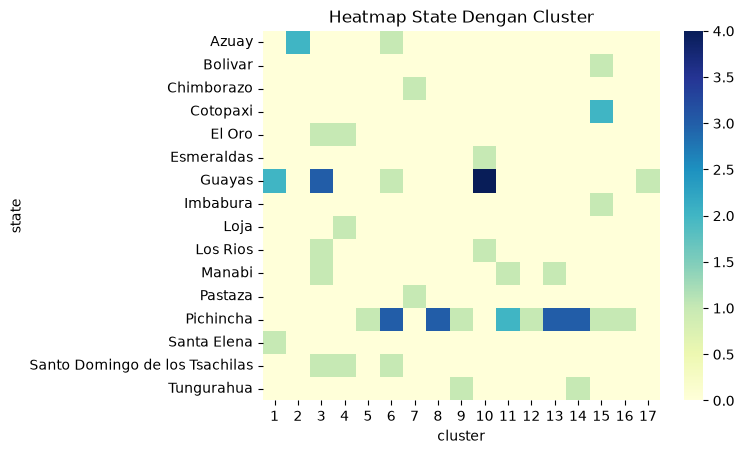

In [45]:
sns.heatmap(location_cluster, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Heatmap State Dengan Cluster')
plt.show()

<Axes: ylabel='cluster'>

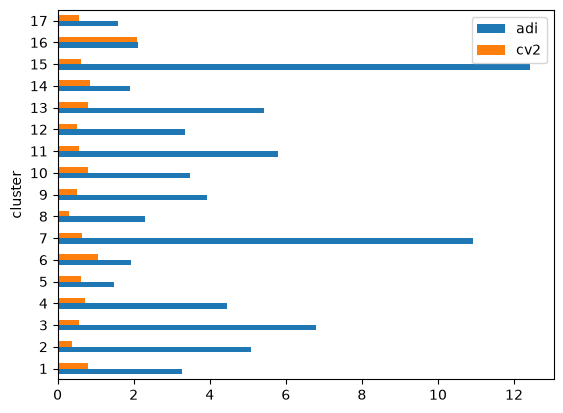

In [46]:
df_full_stats_with_store_info = df_full_stats.merge(stores, on='store_nbr')

cluster_demand_profile = df_full_stats_with_store_info.groupby('cluster')[['adi', 'cv2']].mean()

cluster_demand_profile.sort_values('cluster').plot(kind='barh')

### 1. Penggabungan Data (Data Merging)

In [47]:
# Menggabungkan df_full_stats dengan stores berdasarkan store_nbr
df_merged = df_full_stats.merge(stores, on='store_nbr', how='left')
df_merged.head()

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category,city,state,type,cluster
0,1,AUTOMOTIVE,1463,3.251188,3.0,2.758785,0.0,19.0,1.394908,2.944256,0.848547,1.151059,0.494303,Erratic,Quito,Pichincha,D,13
1,1,BABY CARE,0,0.000000,0.0,0.000000,0.0,0.0,NaN,NaN,0.000000,NaN,NaN,No Sales,Quito,Pichincha,D,13
2,1,BEAUTY,1430,2.408551,2.0,1.898386,0.0,12.0,1.012293,1.407079,0.788186,1.177622,0.376704,Smooth,Quito,Pichincha,D,13
3,1,BEVERAGES,1678,1587.748812,1674.0,726.654208,0.0,5051.0,0.176872,-0.721302,0.457663,1.003576,0.205146,Smooth,Quito,Pichincha,D,13
4,1,BOOKS,127,0.125297,0.0,0.536419,0.0,8.0,6.492349,58.386677,4.281179,13.259843,0.457672,Intermittent,Quito,Pichincha,D,13


### 2. Hubungan cluster dengan Metadata Toko (Kategorikal)
Kita akan menggunakan Uji Chi-Square untuk melihat hubungan antara cluster dengan tipe toko (type), kota (city), dan negara bagian (state).

In [48]:
from scipy.stats import chi2_contingency

# Fungsi untuk uji Chi-Square
def perform_chi2_test(col1, col2, data):
    crosstab = pd.crosstab(data[col1], data[col2])
    chi2, p, dof, expected = chi2_contingency(crosstab)
    print(f"=== Uji Chi-Square antara {col1} dan {col2} ===")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"p-value: {p:.4e}")
    if p < 0.05:
        print(f"Kesimpulan: Terdapat hubungan yang signifikan secara statistik antara {col1} dan {col2} (Tolak H0)")
    else:
        print(f"Kesimpulan: Tidak terdapat hubungan yang signifikan antara {col1} dan {col2} (Terima H0)")
    print("-" * 50)

# Uji untuk metadata toko yang ada di tabel stores
perform_chi2_test('cluster', 'type', stores)
perform_chi2_test('cluster', 'state', stores)
perform_chi2_test('cluster', 'city', stores)

=== Uji Chi-Square antara cluster dan type ===
Chi-square statistic: 189.8750
p-value: 2.1050e-14
Kesimpulan: Terdapat hubungan yang signifikan secara statistik antara cluster dan type (Tolak H0)
--------------------------------------------------
=== Uji Chi-Square antara cluster dan state ===
Chi-square statistic: 264.8667
p-value: 1.2962e-01
Kesimpulan: Tidak terdapat hubungan yang signifikan antara cluster dan state (Terima H0)
--------------------------------------------------
=== Uji Chi-Square antara cluster dan city ===
Chi-square statistic: 319.4786
p-value: 7.3311e-01
Kesimpulan: Tidak terdapat hubungan yang signifikan antara cluster dan city (Terima H0)
--------------------------------------------------


### 3. Hubungan cluster dengan Volume Penjualan (Numerik)
Kita akan melihat distribusi rata-rata penjualan per toko berdasarkan cluster dan menggunakan Kruskal-Wallis Test.

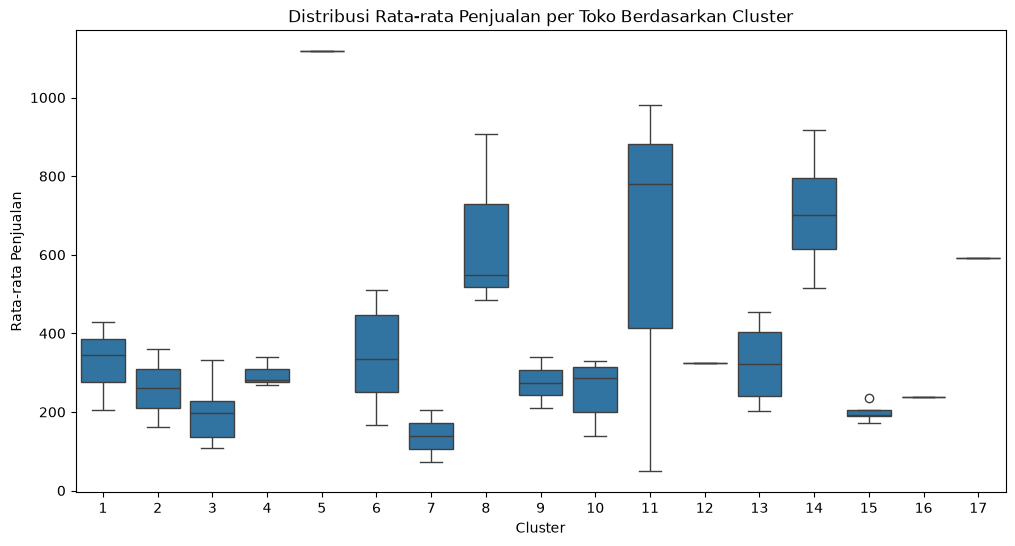

=== Uji Kruskal-Wallis untuk Rata-rata Penjualan antar Cluster ===
Statistic: 29.8442
p-value: 1.8827e-02
Kesimpulan: Terdapat perbedaan rata-rata penjualan yang signifikan antar cluster (Tolak H0).
Lanjut ke uji Dunn's post-hoc test.


In [49]:
# Menghitung rata-rata penjualan per toko
store_sales = train.groupby('store_nbr')['sales'].mean().reset_index()
store_sales = store_sales.merge(stores[['store_nbr', 'cluster']], on='store_nbr', how='left')

# Visualisasi Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=store_sales, x='cluster', y='sales')
plt.title('Distribusi Rata-rata Penjualan per Toko Berdasarkan Cluster')
plt.xlabel('Cluster')
plt.ylabel('Rata-rata Penjualan')
plt.show()

# Uji Kruskal-Wallis
clusters = store_sales['cluster'].unique()
sales_by_cluster = [store_sales[store_sales['cluster'] == c]['sales'].values for c in clusters]
stat, p = kruskal(*sales_by_cluster)
print(f"=== Uji Kruskal-Wallis untuk Rata-rata Penjualan antar Cluster ===")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p:.4e}")
if p < 0.05:
    print("Kesimpulan: Terdapat perbedaan rata-rata penjualan yang signifikan antar cluster (Tolak H0).")
    print("Lanjut ke uji Dunn's post-hoc test.")
else:
    print("Kesimpulan: Tidak terdapat perbedaan rata-rata penjualan yang signifikan antar cluster (Terima H0).")

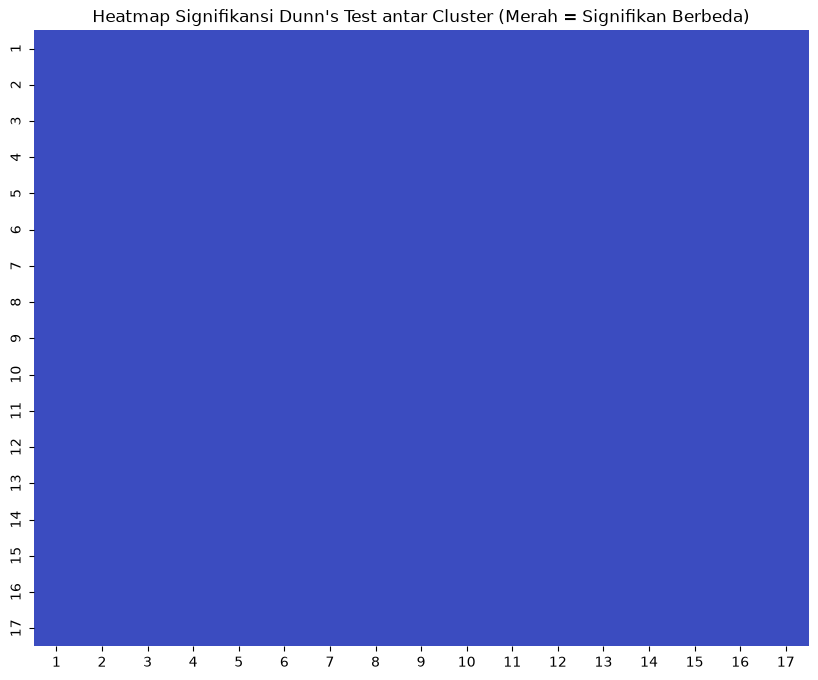

In [50]:
# Dunn's post-hoc test
dunn_cluster = sp.posthoc_dunn(store_sales, val_col='sales', group_col='cluster', p_adjust='bonferroni')

# Menampilkan heatmap dari p-value hasil post-hoc test agar lebih mudah dibaca
plt.figure(figsize=(10, 8))
sns.heatmap(dunn_cluster < 0.05, cmap='coolwarm', cbar=False, annot=False)
plt.title("Heatmap Signifikansi Dunn's Test antar Cluster (Merah = Signifikan Berbeda)")
plt.show()

### 4. Hubungan cluster dengan Kategori Permintaan (ADI & CV2)
Apakah cluster tertentu memiliki kecenderungan tipe kategori permintaan tertentu?

=== Uji Chi-Square antara Cluster dan Kategori Permintaan ===
p-value: 5.4470e-07
Kesimpulan: Terdapat perbedaan proporsi kategori permintaan yang signifikan antar cluster.


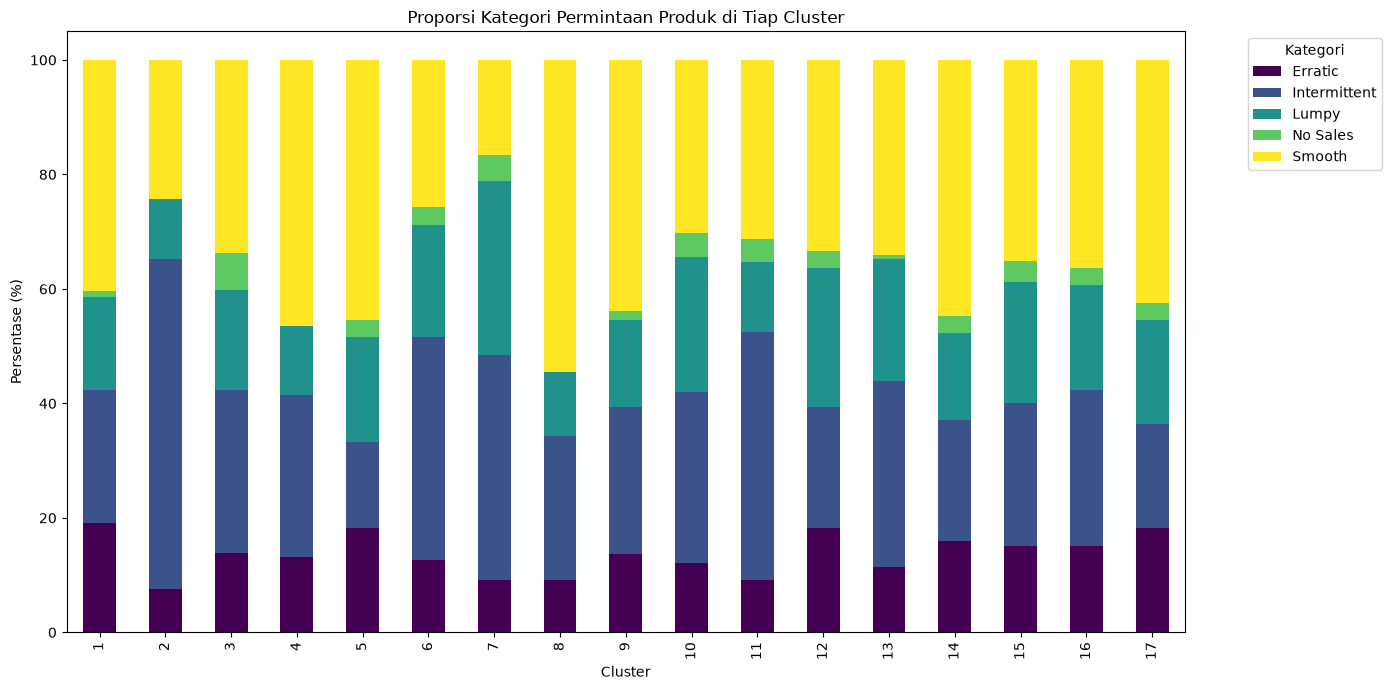

In [51]:
# Menghitung proporsi kategori permintaan per cluster
cluster_demand = pd.crosstab(df_merged['cluster'], df_merged['category'])

# Uji Chi-Square untuk kategori permintaan
chi2, p, dof, expected = chi2_contingency(cluster_demand)
print(f"=== Uji Chi-Square antara Cluster dan Kategori Permintaan ===")
print(f"p-value: {p:.4e}")
if p < 0.05:
    print("Kesimpulan: Terdapat perbedaan proporsi kategori permintaan yang signifikan antar cluster.")
else:
    print("Kesimpulan: Tidak terdapat perbedaan proporsi kategori permintaan yang signifikan antar cluster.")

# Visualisasi Stacked Bar
cluster_demand_pct = cluster_demand.div(cluster_demand.sum(axis=1), axis=0) * 100
cluster_demand_pct.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis')
plt.title('Proporsi Kategori Permintaan Produk di Tiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Persentase (%)')
plt.legend(title='Kategori', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()